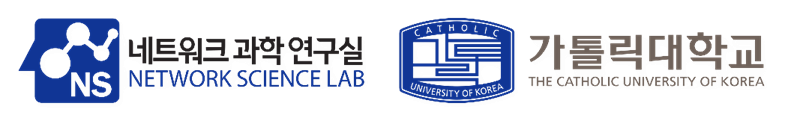

# 🎨 Week 3: The Expressive Power of Graph Neural Networks

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W3/Sample_Code_3.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

### Overview

In Week 2 we built GNNs out of **message passing** and saw that they *work*. This week we ask a sharper
question:

> **What can a GNN actually tell apart — and what is it blind to?**

This is the question of **expressive power**. A GNN that cannot distinguish two graphs must give them
the same prediction, so these limits hold no matter how much data or how many epochs we use.


---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

C_TARGET, C_EDGE, C_DARK, C_PLAIN = '#E74C3C', '#95A5A6', '#2C3E50', '#D5D8DC'

# Color id -> RGBA. Ids 1-9 are pastel hues, 10-18 darker ones, then the cycle repeats.
# Id 0 means "no color" (plain gray), so the grays of tab20 (14, 15) are left out.
_TAB20 = plt.get_cmap('tab20')
_ORDER = [i for i in range(1, 20, 2) if i != 15] + [i for i in range(0, 20, 2) if i != 14]

def color_of(cid):
    return to_rgba(C_PLAIN) if cid == 0 else _TAB20(_ORDER[(int(cid) - 1) % len(_ORDER)])

def ink(rgba):
    """Readable text color on top of `rgba`."""
    r, g, b = rgba[:3]
    return 'white' if 0.299 * r + 0.587 * g + 0.114 * b < 0.5 else C_DARK


def draw_graph(G, pos, ax, colors=None, labels='id', title=None, highlight=None,
               node_size=620, font_size=11):
    """
    Draw G on `ax`.
      colors    : {node: color id}, or None for plain gray nodes
      labels    : 'id' -> node ids, 'color' -> color ids, None -> no labels
      highlight : a node to outline in red
    """
    nodes = list(G.nodes())
    fill = [color_of(colors[v]) if colors is not None else to_rgba(C_PLAIN) for v in nodes]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=2.0)
    nx.draw_networkx_nodes(G, pos, nodelist=nodes, ax=ax, node_color=fill, node_size=node_size,
                           edgecolors=[C_TARGET if v == highlight else C_DARK for v in nodes],
                           linewidths=[3.0 if v == highlight else 1.3 for v in nodes])
    if labels:
        for v, f in zip(nodes, fill):
            text = v if labels == 'id' else colors[v]
            ax.text(*pos[v], str(text), ha='center', va='center', fontsize=font_size,
                    color=ink(f), fontweight='bold' if labels == 'color' else 'normal')
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.15)

---

## 2. The Failure

Consider these two graphs on 6 nodes:

- $C_6$ — a single 6-cycle (one hexagon).
- $2 \times C_3$ — two disjoint triangles.

They are clearly **not isomorphic**: one is connected and triangle-free, the other has two components
and two triangles. Yet every node in both graphs has exactly **degree 2**, and every neighbor of every
node also has degree 2. Locally, all 12 nodes look the same.

C6      | nodes 6 | edges 6 | components 1 | degrees [2, 2, 2, 2, 2, 2] | triangles 0
2 x C3  | nodes 6 | edges 6 | components 2 | degrees [2, 2, 2, 2, 2, 2] | triangles 2
Isomorphic? False


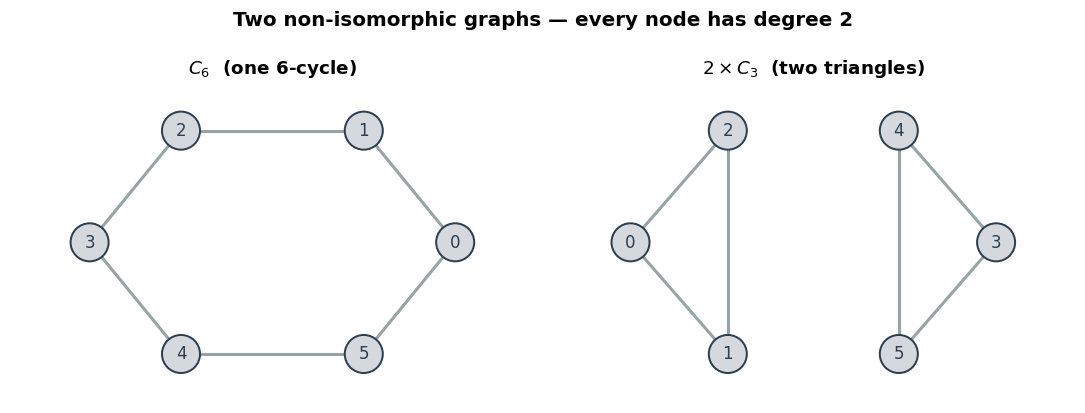

In [2]:
C6    = nx.cycle_graph(6)
TwoC3 = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))

for name, G in [('C6', C6), ('2 x C3', TwoC3)]:
    print(f'{name:7s} | nodes {G.number_of_nodes()} | edges {G.number_of_edges()} '
          f'| components {nx.number_connected_components(G)} '
          f'| degrees {sorted(d for _, d in G.degree())} '
          f'| triangles {sum(nx.triangles(G).values()) // 3}')
print(f'Isomorphic? {nx.is_isomorphic(C6, TwoC3)}')

# Fixed layouts reused by later figures: a hexagon, and two triangles side by side
POS_C6  = nx.circular_layout(C6)
POS_2C3 = {}
for nodes, cx, start in [([0, 1, 2], -1.0, np.pi), ([3, 4, 5], 1.0, 0.0)]:
    for i, n in enumerate(nodes):
        a = start + 2 * np.pi * i / 3
        POS_2C3[n] = np.array([cx + 0.55 * np.cos(a), 0.55 * np.sin(a)])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
draw_graph(C6, POS_C6, axes[0], title='$C_6$  (one 6-cycle)')
draw_graph(TwoC3, POS_2C3, axes[1], title='$2 \\times C_3$  (two triangles)')
fig.suptitle('Two non-isomorphic graphs — every node has degree 2', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

---

## 3. The Computational Graph

### 3.1 What a Node Actually Sees

To compute $h_v^{(L)}$ after $L$ rounds of message passing, node $v$ needs its neighbors' layer-$(L-1)$
states, which need *their* neighbors' layer-$(L-2)$ states, and so on. Unrolling this gives the
**computational graph** of $v$ (also called its **unfolding tree**):

1. Put $v$ at the root.
2. Under every tree node, attach a **copy** of each of its neighbors.
3. Stop after $L$ levels.

Two details matter:

- **It is a tree of copies, not a subgraph.** A node reached by two different walks appears twice, and
  the tree cannot tell that the two copies are the same node.
- **Messages go back and forth**, so $v$ itself reappears at level 2.

Below, the copies of a graph node have the same color as that node.

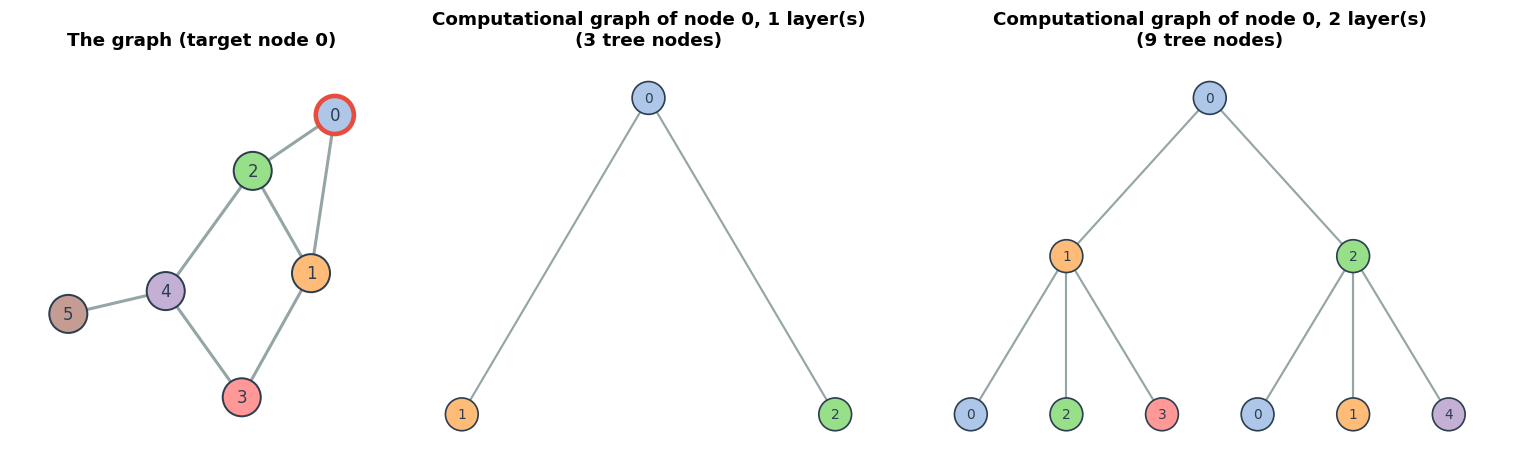

Tree size for L = 0..5 layers: [1, 3, 9, 24, 63, 162]   (the graph has only 6 nodes)


In [3]:
def unfolding_tree(G, root, depth):
    """
    Computational graph of `root` for a `depth`-layer GNN.
    Tree nodes are walks starting at `root`; attribute 'orig' is the graph node a copy stands for.
    Edges point child -> parent, the direction messages flow.
    """
    T = nx.DiGraph()
    T.add_node((root,), orig=root, level=0)
    frontier = [(root,)]
    for d in range(1, depth + 1):
        frontier = [walk + (u,) for walk in frontier for u in sorted(G[walk[-1]])]
        for walk in frontier:
            T.add_node(walk, orig=walk[-1], level=d)
            T.add_edge(walk, walk[:-1])
    return T


def draw_tree(T, ax, uniform=False, title=None, node_size=460, font_size=9):
    """Draw a tree with the root on top. uniform=True paints every copy gray (only shape matters)."""
    pos, next_x = {}, [0.0]

    def place(n):                                   # each parent centered above its children
        kids = sorted(T.predecessors(n))
        if kids:
            x = float(np.mean([place(k) for k in kids]))
        else:
            x, next_x[0] = next_x[0], next_x[0] + 1
        pos[n] = (x, -T.nodes[n]['level'])
        return x

    place(next(n for n in T if T.nodes[n]['level'] == 0))
    nodes = list(T.nodes())
    fill = [color_of(0 if uniform else T.nodes[n]['orig'] + 1) for n in nodes]
    nx.draw_networkx_edges(T, pos, ax=ax, arrows=False, edge_color=C_EDGE, width=1.4)
    nx.draw_networkx_nodes(T, pos, nodelist=nodes, ax=ax, node_color=fill,
                           edgecolors=C_DARK, linewidths=1.1, node_size=node_size)
    for n, f in zip(nodes, fill):
        ax.text(*pos[n], str(T.nodes[n]['orig']), ha='center', va='center',
                fontsize=font_size, color=ink(f))
    if title:
        ax.set_title(title)
    ax.set_axis_off()
    ax.margins(0.08)


G_demo = nx.Graph([(0, 1), (0, 2), (1, 2), (1, 3), (2, 4), (3, 4), (4, 5)])
POS_DEMO = nx.spring_layout(G_demo, seed=3)

fig = plt.figure(figsize=(14, 4.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1.25, 1.6])
draw_graph(G_demo, POS_DEMO, fig.add_subplot(gs[0]), colors={v: v + 1 for v in G_demo},
           highlight=0, title='The graph (target node 0)')
for k, depth in enumerate([1, 2]):
    T = unfolding_tree(G_demo, 0, depth)
    draw_tree(T, fig.add_subplot(gs[k + 1]),
              title=f'Computational graph of node 0, {depth} layer(s)\n'
                    f'({T.number_of_nodes()} tree nodes)')
plt.tight_layout(); plt.show()

sizes = [unfolding_tree(G_demo, 0, L).number_of_nodes() for L in range(6)]
print(f'Tree size for L = 0..5 layers: {sizes}   (the graph has only {G_demo.number_of_nodes()} nodes)')

**Read the tree bottom-up.** Leaves send their features to their parents, which combine them and pass
the result upward; after $L$ steps the root holds $h_0^{(L)}$. The tree grows roughly like $d^L$ for
average degree $d$, which is why deep GNNs suffer from **over-squashing**: exponentially much
information is squeezed into one fixed-size vector.

### 3.2 The Key Lemma

> A message-passing GNN computes $h_v^{(L)}$ from the depth-$L$ computational graph of $v$ and
> *nothing else*. So if two nodes (even in different graphs) have **identical** computational graphs,
> **every** GNN gives them the **same** embedding, whatever its weights.

The GNN never sees the graph, only rooted trees. Let's apply this to $C_6$ and $2 \times C_3$. All input
features are identical, so only the *shape* of the tree can matter; we paint every copy gray.

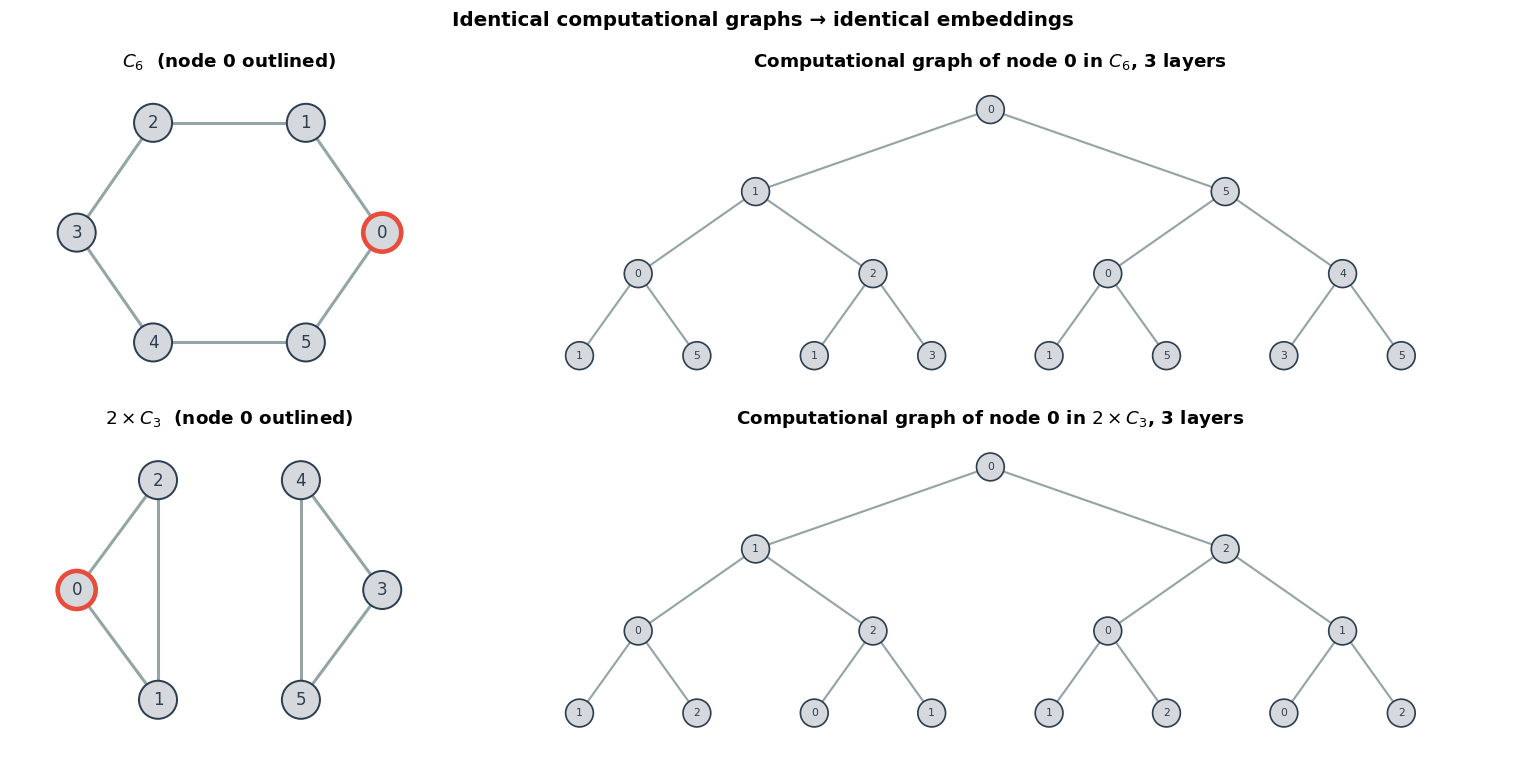

All 6 x 6 node pairs (C6 node, 2xC3 node) have identical trees for L = 1..4: True


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'width_ratios': [1, 2.4]})
for row, (name, G, pos) in enumerate([('$C_6$', C6, POS_C6), ('$2 \\times C_3$', TwoC3, POS_2C3)]):
    draw_graph(G, pos, axes[row, 0], highlight=0, title=f'{name}  (node 0 outlined)')
    draw_tree(unfolding_tree(G, 0, 3), axes[row, 1], uniform=True, node_size=330, font_size=7,
              title=f'Computational graph of node 0 in {name}, 3 layers')
fig.suptitle('Identical computational graphs → identical embeddings', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


def tree_shape(T, n):
    """Canonical form of the subtree at n, ignoring which graph node each copy is."""
    return tuple(sorted(tree_shape(T, k) for k in T.predecessors(n)))

same = all(tree_shape(unfolding_tree(C6, u, L), (u,)) == tree_shape(unfolding_tree(TwoC3, v, L), (v,))
           for L in range(1, 5) for u in C6 for v in TwoC3)
print(f'All 6 x 6 node pairs (C6 node, 2xC3 node) have identical trees for L = 1..4: {same}')

Both trees are the **same perfect binary tree**: every node has two neighbors, so every copy branches in
two at every level. The cycle lengths (6 vs. 3) are invisible because a tree has no cycles to record.
So all 12 nodes get the same embedding in every GNN, and so do the two graphs.

Building these trees costs exponential time. Next we see a cheap way to compare them: **color refinement**.

---

## 4. Color Refinement (the 1-WL Algorithm)

### 4.1 The Rule

Give every node a color, then repeat:

$$c^{(\ell)}(v) \;=\; \mathrm{HASH}\Big(\, c^{(\ell-1)}(v), \;\; \{\!\!\{\, c^{(\ell-1)}(u) \;:\; u \in \mathcal{N}(v) \,\}\!\!\} \,\Big)$$

Each round has two steps:

1. **Aggregate neighboring colors.** Every node collects its own color and the **multiset** of its
   neighbors' colors (a multiset ignores order but keeps counts). We write this *aggregated color* as
   `own,{neighbors}`: a node of color 1 with two neighbors of color 1 has aggregated color `1,{1,1}`.
2. **Injectively hash the aggregated colors.** Every distinct aggregated color gets its own new color,
   so different inputs never share an output. Real implementations use a hash function; we simply
   number the new colors 2, 3, 4, … in order of first appearance and write them in a **HASH table**.
   Both graphs share one table, so the same color means the same thing in both graphs.

Why this is the right tool:

- **It mirrors message passing**: (own state, multiset of neighbor states) → new state.
- **Colors encode computational graphs**: $c^{(\ell)}(u) = c^{(\ell)}(v)$ **iff** $u$ and $v$ have
  identical depth-$\ell$ computational graphs.
- **It is cheap**: $O(L \cdot |E|)$ time instead of exponentially large trees.

In [5]:
def aggregate(G, colors):
    """Step 2: aggregated color of every node = (own color, sorted tuple of neighbor colors)."""
    return {v: (colors[v], tuple(sorted(colors[u] for u in G[v]))) for v in G}


def wl_refine(graphs, num_iterations=3):
    """
    Color refinement run jointly on a list of graphs with one shared HASH table.

    Returns `rounds`, where rounds[l] is a dict:
        'colors' : [{node: color} per graph]             colors after round l
        'agg'    : [{node: aggregated color} per graph]  what was hashed in round l
        'table'  : {aggregated color: new color}         the HASH table of round l
    rounds[0] is the initial coloring: every node gets color 1.
    """
    rounds = [{'colors': [{v: 1 for v in G} for G in graphs], 'agg': None, 'table': {}}]
    next_color = 2
    for _ in range(num_iterations):
        agg = [aggregate(G, c) for G, c in zip(graphs, rounds[-1]['colors'])]
        # Step 3: injective hash. Every unseen aggregated color gets the next unused number.
        # (Each round's inputs use fresh colors, so each round needs only its own table.)
        table = {}
        for a in agg:
            for sig in a.values():
                if sig not in table:
                    table[sig] = next_color
                    next_color += 1
        colors = [{v: table[sig] for v, sig in a.items()} for a in agg]
        rounds.append({'colors': colors, 'agg': agg, 'table': table})
    return rounds


def color_histogram(colors):
    """How many nodes carry each color: the graph-level fingerprint."""
    return dict(sorted(Counter(colors.values()).items()))


def wl_report(rounds, names):
    """The WL test: compare the two graphs' color histograms round by round."""
    differ = False
    for l, r in enumerate(rounds):
        h1, h2 = (color_histogram(c) for c in r['colors'])
        differ = differ or h1 != h2
        print(f"round {l}:  {names[0]} {str(h1):<34s} {'==' if h1 == h2 else '!='}  {names[1]} {h2}")
    print('\n→ NON-ISOMORPHIC (the histograms differ)' if differ else
          '\n→ INCONCLUSIVE (the histograms are always equal)')


# ---- drawing -------------------------------------------------------------------------
def fmt_agg(sig):
    """(3, (3, 4)) -> '3,{3,4}'"""
    own, nbrs = sig
    return f"{own},{{{','.join(map(str, nbrs))}}}"


def draw_aggregated(G, pos, ax, colors, agg, title=None):
    """Each node is a box showing its aggregated color, filled with its current color."""
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C_EDGE, width=2.0)
    for v in G:
        f = color_of(colors[v])
        ax.text(*pos[v], fmt_agg(agg[v]), ha='center', va='center', fontsize=10, color=ink(f),
                bbox=dict(boxstyle='round,pad=0.35', fc=f, ec=C_DARK, lw=1.2))
    xs, ys = zip(*pos.values())
    ax.set_xlim(min(xs) - 0.5, max(xs) + 0.5)
    ax.set_ylim(min(ys) - 0.4, max(ys) + 0.4)
    if title:
        ax.set_title(title)
    ax.set_axis_off()


def draw_hash_table(ax, table, title):
    tab = ax.table(cellText=[[fmt_agg(sig), c] for sig, c in table.items()],
                   colLabels=['aggregated color', 'new color'], loc='center', cellLoc='center')
    tab.auto_set_font_size(False); tab.set_fontsize(11); tab.scale(1, 1.7)
    for j in range(2):                                   # header row
        tab[0, j].set_facecolor(C_DARK)
        tab[0, j].get_text().set(color='white', fontweight='bold')
    for i, c in enumerate(table.values(), start=1):      # paint each new color
        tab[i, 1].set_facecolor(color_of(c))
        tab[i, 1].get_text().set(color=ink(color_of(c)), fontweight='bold')
    ax.set_title(title)
    ax.set_axis_off()


def show_initial(graphs, names, positions, rounds):
    fig, axes = plt.subplots(1, len(graphs), figsize=(11, 3))
    for ax, G, name, pos, c in zip(axes, graphs, names, positions, rounds[0]['colors']):
        draw_graph(G, pos, ax, colors=c, labels='color', title=name)
    fig.suptitle('Step 1 · Assign initial colors: every node gets color 1',
                 fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


def show_round(graphs, names, positions, rounds, l):
    """One round, left to right: aggregated colors -> HASH table -> new colors."""
    r, prev = rounds[l], rounds[l - 1]['colors']
    fig = plt.figure(figsize=(15, 5.6))
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 0.75, 1])
    for i, (G, name, pos) in enumerate(zip(graphs, names, positions)):
        draw_aggregated(G, pos, fig.add_subplot(gs[i, 0]), prev[i], r['agg'][i],
                        title=f'{name}: aggregated colors')
        draw_graph(G, pos, fig.add_subplot(gs[i, 2]), colors=r['colors'][i], labels='color',
                   title=f'{name}: new colors')
    draw_hash_table(fig.add_subplot(gs[:, 1]), r['table'], title=f'HASH table (round {l})')
    fig.suptitle(f'Round {l}:   Step 2 · aggregate neighboring colors   →   '
                 f'Step 3 · injectively hash   →   new colors', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

### 4.2 Color Refinement 
We refine two small graphs side by side:

- $G_1$ — a triangle with a tail of length 3,
- $G_2$ — a square with a tail of length 2.

Both have 6 nodes, 6 edges and the **same degree sequence** (3, 2, 2, 2, 2, 1), so counting degrees
cannot tell them apart. Can color refinement?

**Step 1 — Assign initial colors.** There are no node features, so every node starts with color 1.

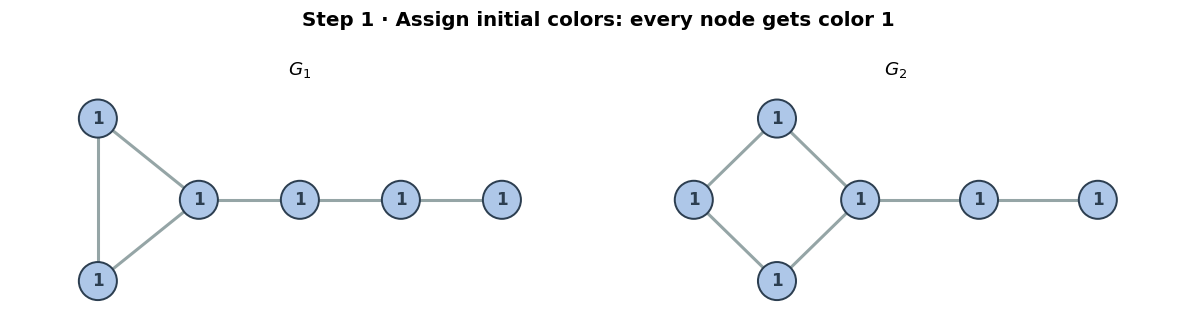

In [6]:
G1 = nx.Graph([(0, 1), (1, 2), (2, 0), (2, 3), (3, 4), (4, 5)])     # triangle + tail
G2 = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 0), (3, 4), (4, 5)])     # square + tail
POS_G1 = {0: (0, 0.6), 1: (0, -0.6), 2: (1, 0), 3: (2, 0), 4: (3, 0), 5: (4, 0)}
POS_G2 = {0: (0.7, 0.7), 1: (0, 0), 2: (0.7, -0.7), 3: (1.4, 0), 4: (2.4, 0), 5: (3.4, 0)}

PAIR = dict(graphs=[G1, G2], names=['$G_1$', '$G_2$'], positions=[POS_G1, POS_G2])
rounds = wl_refine(PAIR['graphs'], num_iterations=2)

show_initial(**PAIR, rounds=rounds)

**Round 1**

**Step 2 — Aggregate neighboring colors.** Every node writes down its own color and its neighbors'
colors. In the left column each node is replaced by a box showing its **aggregated color**, e.g.
`1,{1,1,1}` for the node with three neighbors.

**Step 3 — Injectively hash the aggregated colors.** The HASH table (middle) gives every distinct
aggregated color a new number, and the nodes are recolored with it (right).

After one round, the colors are just the **degrees** in disguise (2 = degree 2, 3 = degree 3,
4 = degree 1), and both graphs have the same colors in the same amounts.

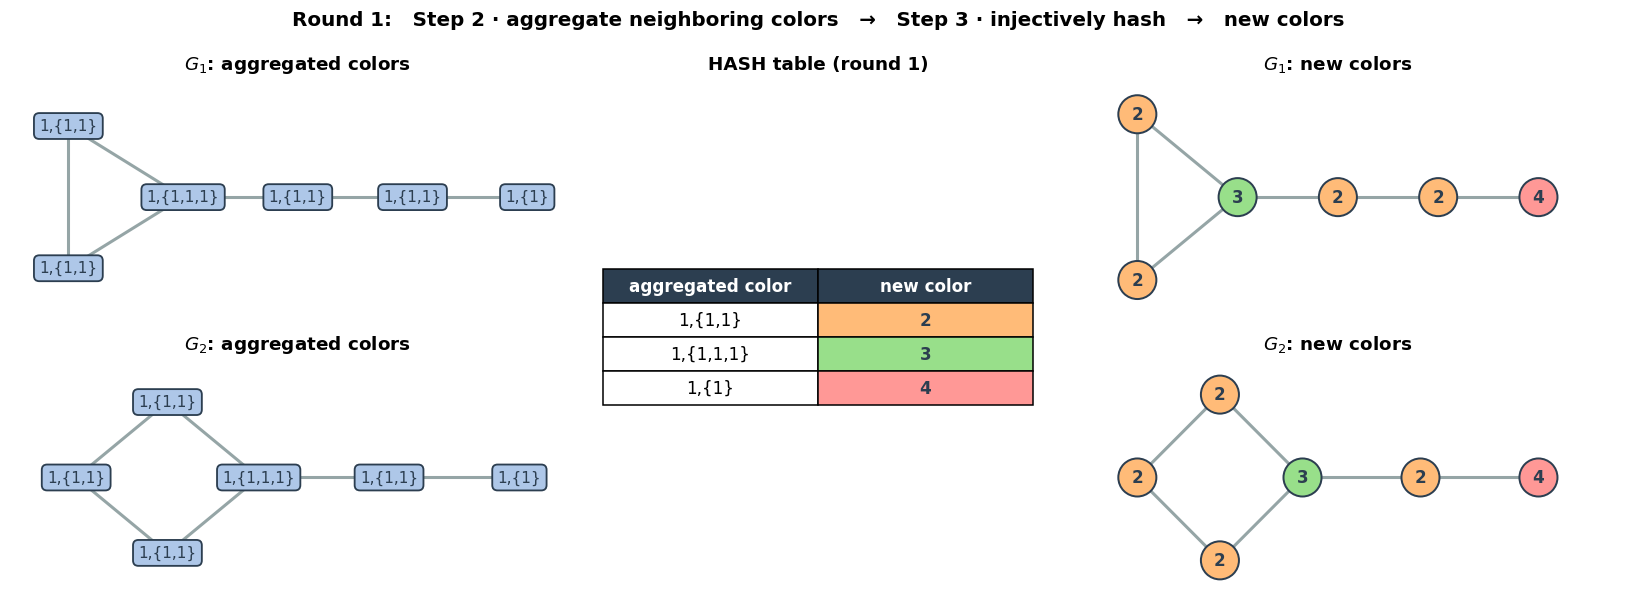

In [7]:
show_round(**PAIR, rounds=rounds, l=1)

**Round 2 — repeat Steps 2 and 3 on the new colors.** Now every node also sees its *neighbors'*
degrees. Colors from round 1 are never reused: the new colors continue at 5, 6, 7, …

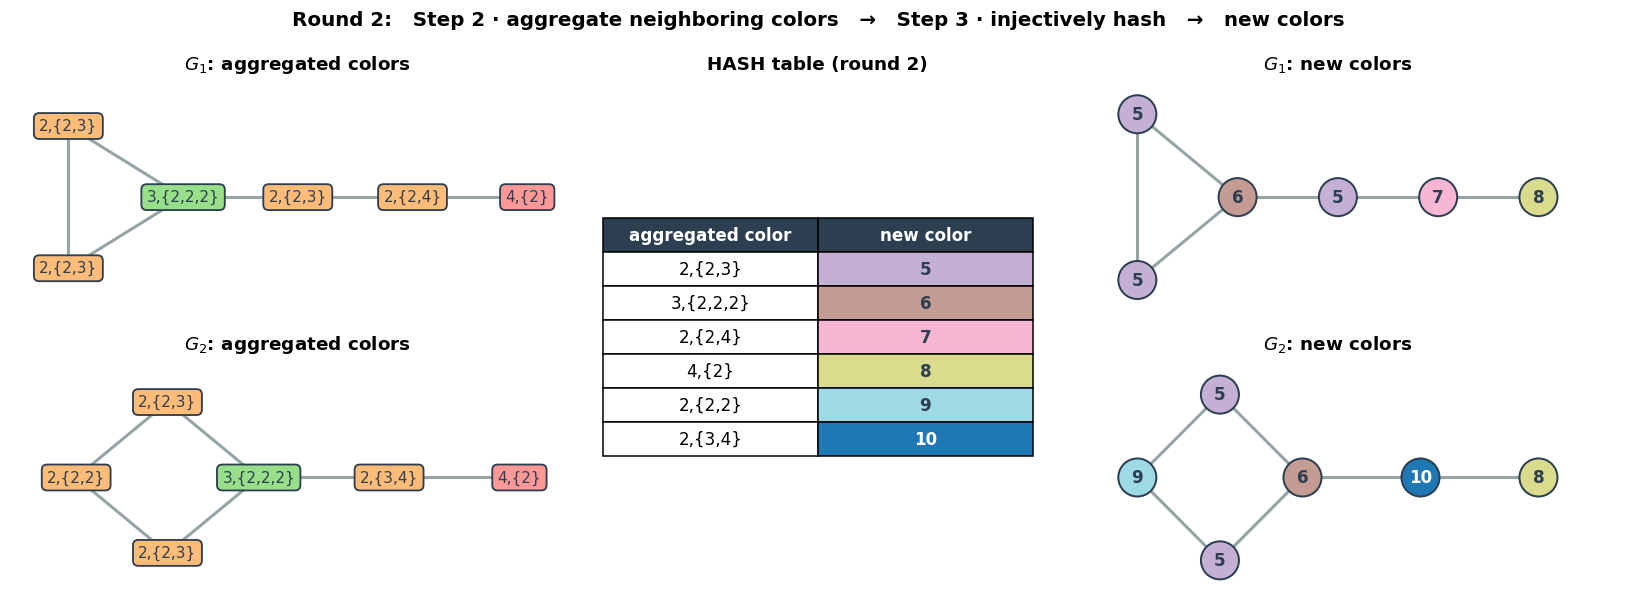

In [8]:
show_round(**PAIR, rounds=rounds, l=2)

**Compare the two graphs.** Count how many nodes carry each color, the **color histogram**. If the
histograms differ in any round, the graphs **cannot** be isomorphic.

In [9]:
wl_report(rounds, ['G1', 'G2'])

round 0:  G1 {1: 6}                             ==  G2 {1: 6}
round 1:  G1 {2: 4, 3: 1, 4: 1}                 ==  G2 {2: 4, 3: 1, 4: 1}
round 2:  G1 {5: 3, 6: 1, 7: 1, 8: 1}           !=  G2 {5: 2, 6: 1, 8: 1, 9: 1, 10: 1}

→ NON-ISOMORPHIC (the histograms differ)


Round 1 only saw degrees, which match. Round 2 finds the difference:

- Color 9 = `2,{2,2}` (a degree-2 node whose two neighbors also have degree 2) exists only in $G_2$:
  the square corner opposite the tail.
- Color 7 = `2,{2,4}` (a degree-2 node next to a degree-1 node and a degree-2 node) exists only in
  $G_1$, whose tail is longer.

So **color refinement separates $G_1$ and $G_2$ even though their degree sequences are identical.**

### 4.3 The WL Test on $C_6$ vs. $2 \times C_3$

Now the same steps on our two failure graphs. The test is **one-sided**:

- histograms differ $\Rightarrow$ **not isomorphic** (always correct);
- histograms always equal $\Rightarrow$ **inconclusive**: the graphs may be isomorphic, or 1-WL is too weak.

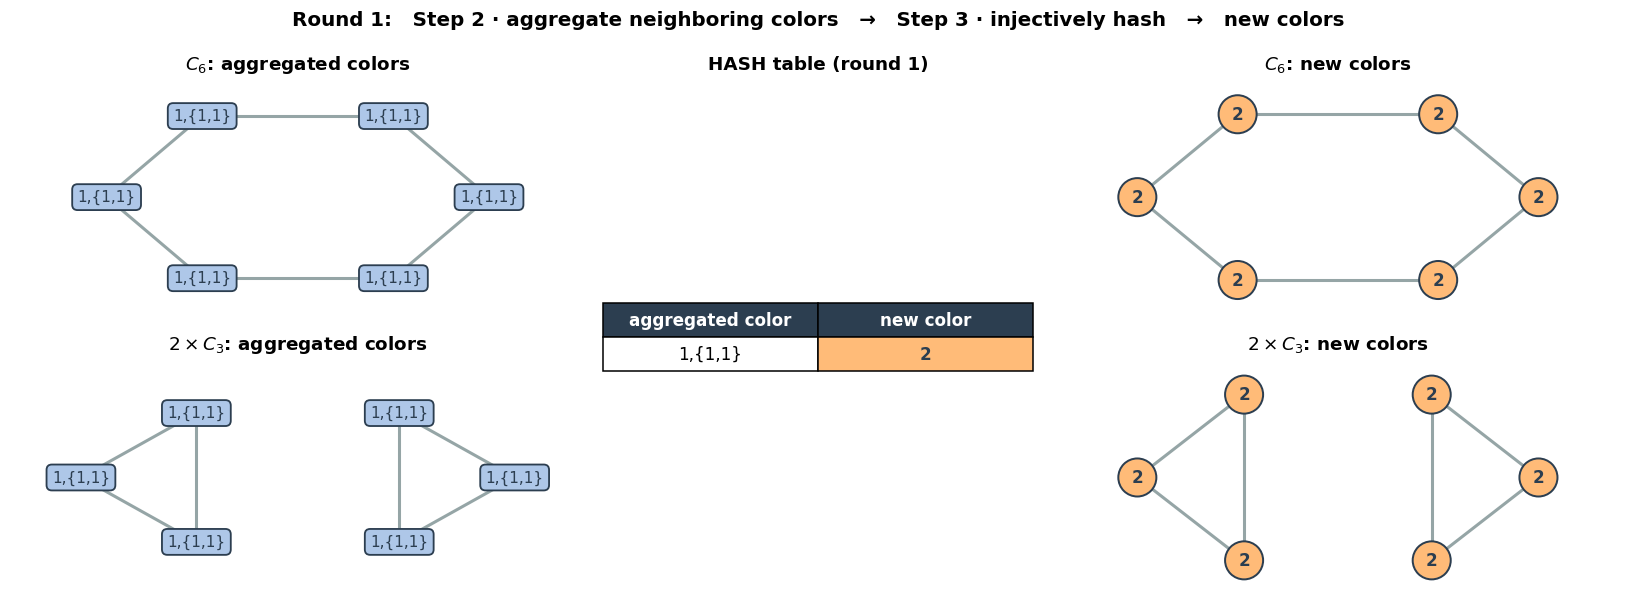

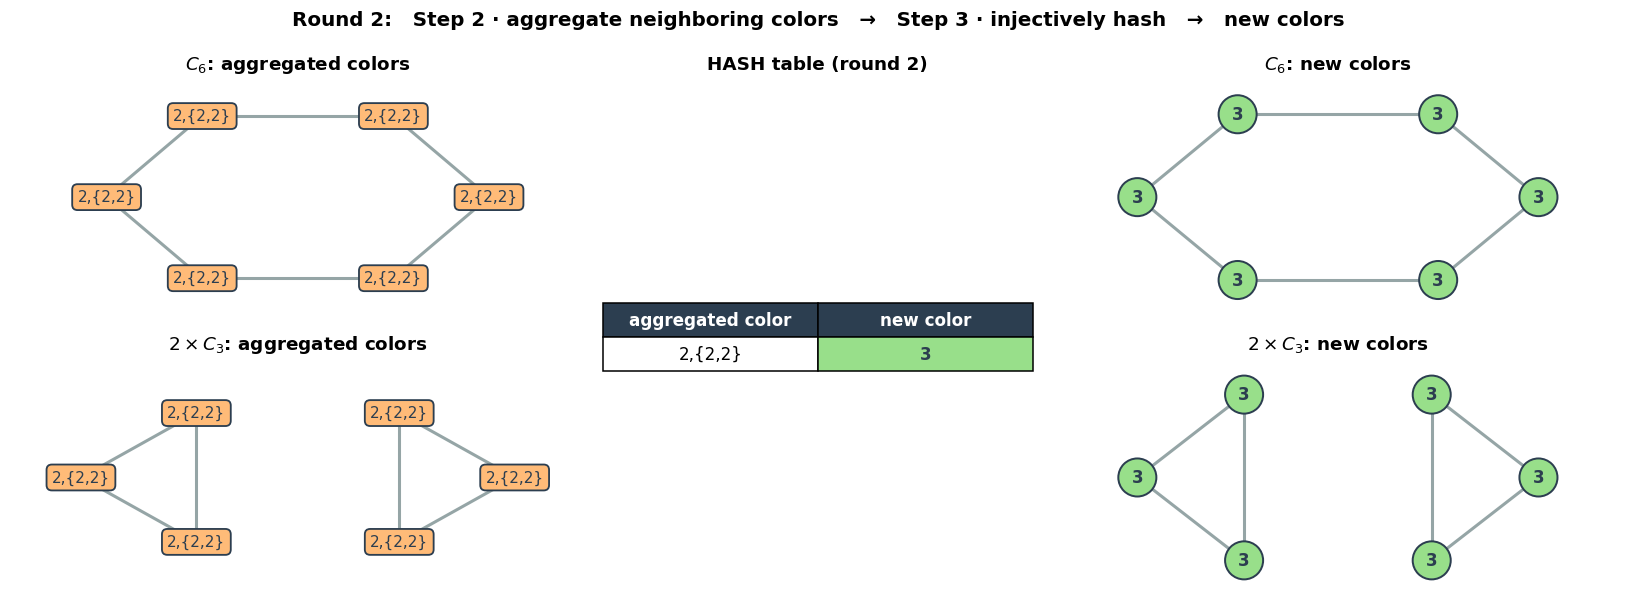

round 0:  C6   {1: 6}                             ==  2xC3 {1: 6}
round 1:  C6   {2: 6}                             ==  2xC3 {2: 6}
round 2:  C6   {3: 6}                             ==  2xC3 {3: 6}
round 3:  C6   {4: 6}                             ==  2xC3 {4: 6}
round 4:  C6   {5: 6}                             ==  2xC3 {5: 6}

→ INCONCLUSIVE (the histograms are always equal)


In [10]:
CYCLES = dict(graphs=[C6, TwoC3], names=['$C_6$', '$2 \\times C_3$'], positions=[POS_C6, POS_2C3])
rounds_cyc = wl_refine(CYCLES['graphs'], num_iterations=4)

for l in [1, 2]:
    show_round(**CYCLES, rounds=rounds_cyc, l=l)

wl_report(rounds_cyc, ['C6  ', '2xC3'])

Every HASH table has **a single row**: every node in both graphs always has the same aggregated color,
so refinement never splits anything and the histograms stay equal forever. This is the computational
graph argument from Section 3 again: same colors ⇔ same trees.

As a check, NetworkX's own WL hash, an independent implementation, agrees on both pairs:

In [11]:
def nx_wl_equal(A, B):
    return nx.weisfeiler_lehman_graph_hash(A, iterations=4) == nx.weisfeiler_lehman_graph_hash(B, iterations=4)

print(f'networkx WL hash equal?  C6 vs 2xC3: {nx_wl_equal(C6, TwoC3)}   |   G1 vs G2: {nx_wl_equal(G1, G2)}')

networkx WL hash equal?  C6 vs 2xC3: True   |   G1 vs G2: False


### 4.4 Refinement Stabilizes Quickly

Refinement can only **split** color classes, never merge them. With at most $n$ classes, the partition
stops changing after at most $n-1$ rounds, usually far sooner. From then on more rounds (more GNN
layers) cannot distinguish anything new.

On the right, the Karate club network after 3 rounds: nodes that share a color are **structurally
indistinguishable** to 1-WL, and so to every message-passing GNN. Nodes whose color is unique are gray.

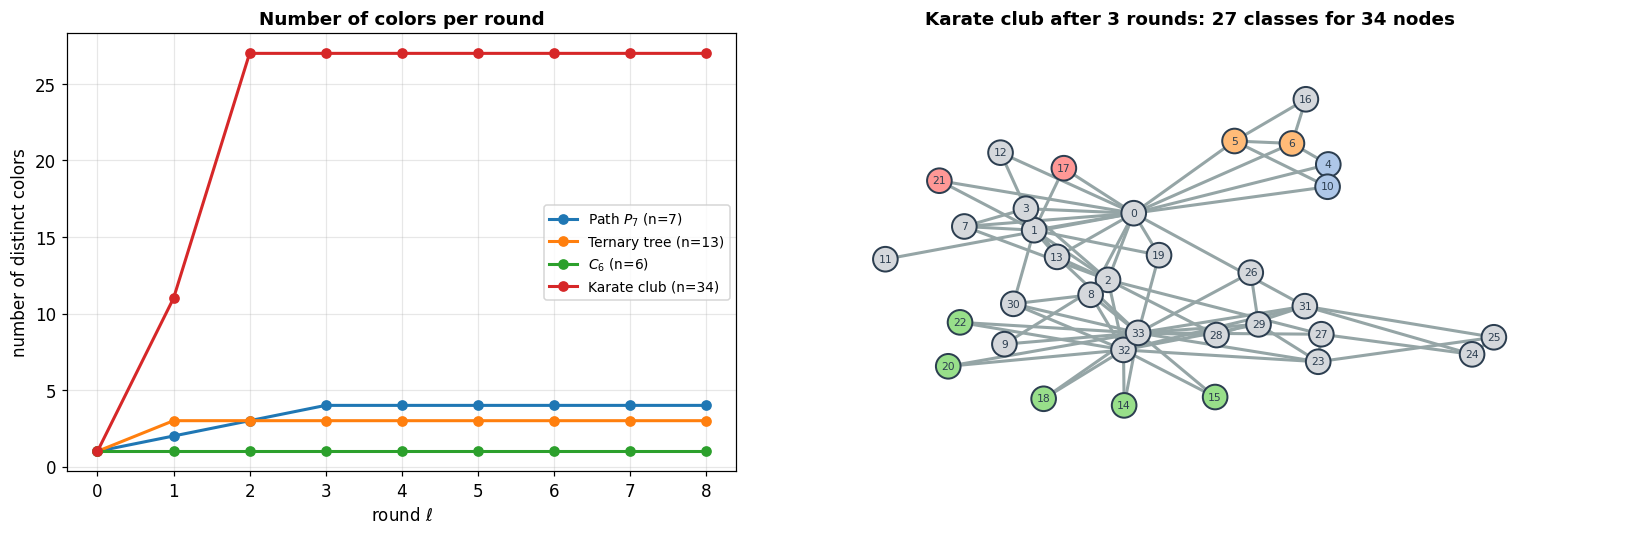

indistinguishable: nodes [4, 10]  (degrees [3, 3])
indistinguishable: nodes [5, 6]  (degrees [4, 4])
indistinguishable: nodes [14, 15, 18, 20, 22]  (degrees [2, 2, 2, 2, 2])
indistinguishable: nodes [17, 21]  (degrees [2, 2])


In [12]:
KC = nx.karate_club_graph()
examples = {'Path $P_7$': nx.path_graph(7), 'Ternary tree': nx.balanced_tree(3, 2),
            '$C_6$': C6, 'Karate club': KC}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.3]})
for name, G in examples.items():
    counts = [len(set(r['colors'][0].values())) for r in wl_refine([G], 8)]
    ax1.plot(counts, marker='o', lw=2, label=f'{name} (n={G.number_of_nodes()})')
ax1.set(xlabel='round $\\ell$', ylabel='number of distinct colors',
        title='Number of colors per round')
ax1.grid(alpha=0.3); ax1.legend(fontsize=9)

# Recolor for display: classes with 2+ nodes get colors 1, 2, ...; unique nodes get 0 (gray)
final = wl_refine([KC], 3)[-1]['colors'][0]
sizes = Counter(final.values())
shared = {c: i for i, c in enumerate(sorted(c for c in sizes if sizes[c] > 1), start=1)}
draw_graph(KC, nx.spring_layout(KC, seed=42, k=0.5), ax2,
           colors={v: shared.get(c, 0) for v, c in final.items()}, node_size=260, font_size=7,
           title=f'Karate club after 3 rounds: {len(sizes)} classes for {KC.number_of_nodes()} nodes')
plt.tight_layout(); plt.show()

for c in shared:
    vs = [v for v in KC if final[v] == c]
    print(f'indistinguishable: nodes {vs}  (degrees {[KC.degree(v) for v in vs]})')